In [2]:
import pandas as pd
import numpy as np
from warnings import filterwarnings
from swings_detection import detect_swing
filterwarnings('ignore')




In [22]:
data = pd.read_csv('gold_data_5_minutes_completed.csv', index_col='timestamp', parse_dates=True)
data = data[['o','h','l','c']]
detect_swing(data, 'high',6)
detect_swing(data, 'low',6)

swings_high with window=6 added to DataFrame
swings_low with window=6 added to DataFrame


,o,h,l,c,swings_high,swings_low
timestamp,,,,,,
2023-06-14 00:00:00,1944.19,1944.58,1942.30,1943.41,False,False
2023-06-14 00:05:00,1943.66,1944.48,1943.00,1944.48,False,False
2023-06-14 00:10:00,1944.82,1944.88,1944.00,1944.49,False,False
2023-06-14 00:15:00,1944.75,1945.36,1944.75,1945.36,False,False
2023-06-14 00:20:00,1945.23,1945.23,1944.60,1945.08,False,False
...,...,...,...,...,...,...
2025-06-02 23:35:00,3383.17,3386.05,3383.17,3386.05,False,False
2025-06-02 23:40:00,3384.40,3386.58,3384.40,3386.31,False,False
2025-06-02 23:45:00,3385.93,3387.00,3384.20,3385.72,False,False


In [23]:
print(data['swings_high'].value_counts())
print(data['swings_low'].value_counts())

swings_high
False    131518
True       6567
Name: count, dtype: int64
swings_low
False    131205
True       6880
Name: count, dtype: int64


In [24]:
data['swings_high_price'] = np.where(data['swings_high'], data['h'], np.nan)
data['swings_low_price'] = np.where(data['swings_low'], data['l'], np.nan)
data['swings_high_price'] = data['swings_high_price'].fillna(method='ffill')
data['swings_low_price'] = data['swings_low_price'].fillna(method='ffill')
data.head(20)

,o,h,l,c,swings_high,swings_low,swings_high_price,swings_low_price
timestamp,,,,,,,,
2023-06-14 00:00:00,1944.19,1944.58,1942.30,1943.41,False,False,NaN,NaN
2023-06-14 00:05:00,1943.66,1944.48,1943.00,1944.48,False,False,NaN,NaN
2023-06-14 00:10:00,1944.82,1944.88,1944.00,1944.49,False,False,NaN,NaN
2023-06-14 00:15:00,1944.75,1945.36,1944.75,1945.36,False,False,NaN,NaN
2023-06-14 00:20:00,1945.23,1945.23,1944.60,1945.08,False,False,NaN,NaN
2023-06-14 00:25:00,1945.08,1945.15,1944.20,1945.07,False,False,NaN,NaN
2023-06-14 00:30:00,1945.16,1945.53,1944.60,1945.01,True,False,1945.53,NaN
2023-06-14 00:35:00,1945.08,1945.29,1944.95,1945.19,False,False,1945.53,NaN
2023-06-14 00:40:00,1944.99,1945.19,1944.70,1944.71,False,False,1945.53,NaN


In [25]:
data.dropna(inplace=True)

In [26]:
conditions = [
    data['swings_high_price'].shift(1) < data['c'],
    data['swings_low_price'].shift(1) > data['c']
]

choices = ['Bullish', 'Bearish']

data['structural_break'] = np.select(conditions, choices, default=None)

In [27]:
data['structural_break'].value_counts(dropna=False)


structural_break
None       102712
Bullish     20956
Bearish     14408
Name: count, dtype: int64

In [28]:
liquidity_grab_conditions = [(data['l'] < data['swings_low_price'].shift(1)) & 
    (data['c'] > data['swings_low_price'].shift(1)),
    (data['h'] > data['swings_high_price'].shift(1)) & 
    (data['c'] < data['swings_high_price'].shift(1))
    ]
liquidity_grab_choices = [
  'Bearish_Grab','Bullish_Grab'
]
data['liquidity_grab'] = np.select(liquidity_grab_conditions,liquidity_grab_choices,default = None)


In [29]:
data['liquidity_grab'].value_counts(dropna=False)

liquidity_grab
None            131042
Bearish_Grab      3741
Bullish_Grab      3293
Name: count, dtype: int64

In [30]:
entry_signal_conditions = [(data['liquidity_grab'].shift(1) == 'Bullish_Grab') & (data['c'] > data['o']),(data['liquidity_grab'].shift(1) == 'Bearish_Grab') & (data['c'] < data['o'])]
entry_signal_choices = [1,-1]
data['entry_signal'] = np.select(entry_signal_conditions,entry_signal_choices,default = np.nan)


In [31]:
data['entry_signal'].value_counts(dropna=False)

entry_signal
 NaN    134372
-1.0      1890
 1.0      1814
Name: count, dtype: int64

In [32]:
data['entry_signal'] = data['entry_signal'].ffill().fillna(0)

In [33]:
data['entry_signal'].value_counts()

entry_signal
-1.0    69749
 1.0    68268
 0.0       59
Name: count, dtype: int64

In [34]:

results = []
in_position = False
position = 0
entry_price = None
entry_time = None

for i in range(1, len(data)):
    signal = data['entry_signal'].iloc[i]
    price_now = data['o'].iloc[i]
    time_now = data.index[i]
    
    if not in_position:
        if signal != 0:
            # Enter first position
            position = signal
            entry_price = price_now
            entry_time = time_now
            in_position = True
    elif signal != position and signal != 0:
        # Reverse position
        exit_price = price_now
        exit_time = time_now
        pnl = (exit_price - entry_price) * position
        
        results.append({
            'Entry Time': entry_time,
            'Exit Time': exit_time,
            'Direction': 'Long' if position == 1 else 'Short',
            'Entry Price': entry_price,
            'Exit Price': exit_price,
            'PnL': pnl
        })
        
        # New position
        entry_price = price_now
        entry_time = time_now
        position = signal

# Final exit if still holding
if in_position:
    exit_price = data['c'].iloc[-1]
    exit_time = data.index[-1]
    pnl = (exit_price - entry_price) * position
    results.append({
        'Entry Time': entry_time,
        'Exit Time': exit_time,
        'Direction': 'Long' if position == 1 else 'Short',
        'Entry Price': entry_price,
        'Exit Price': exit_price,
        'PnL': pnl
    })

# Convert to DataFrame
bt = pd.DataFrame(results)
bt['Cumulative PnL'] = bt['PnL'].cumsum()


In [35]:
print(bt['Cumulative PnL'].iloc[-1])

2878.53


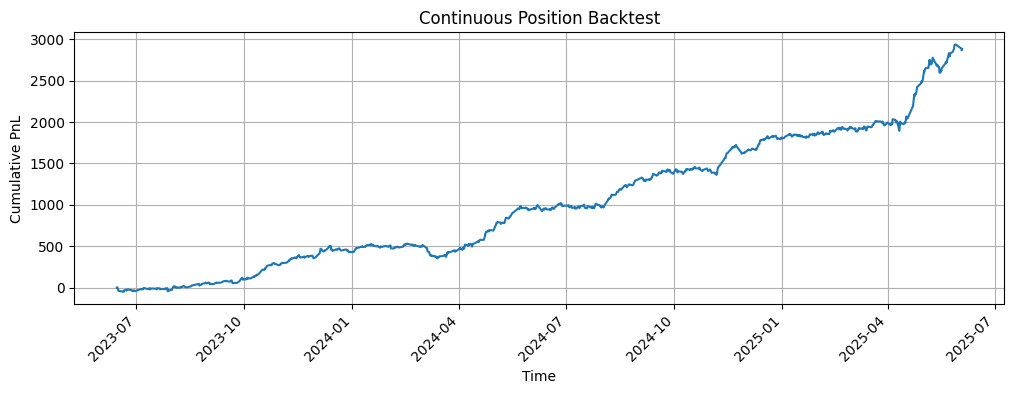

In [36]:
import matplotlib.pyplot as plt

# Set Exit Time as index for plotting
bt_plot = bt.set_index('Exit Time')

# Plot cumulative PnL with time on X-axis
bt_plot['Cumulative PnL'].plot(title='Continuous Position Backtest', figsize=(12, 4))
plt.xlabel("Time")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [37]:
mae_list = []
mfe_list = []

for idx, row in bt.iterrows():
    entry_time = row['Entry Time']
    exit_time = row['Exit Time']
    entry_price = row['Entry Price']
    direction = 1 if row['Direction'] == 'Long' else -1
    
    # Slice the original price data between entry and exit (inclusive)
    trade_data = data.loc[entry_time:exit_time]
    
    # For each candle in trade, calculate price difference vs entry
    if direction == 1:
        # Long trade: adverse = lowest low, favorable = highest high
        min_low = trade_data['l'].min()
        max_high = trade_data['h'].max()
        mae = min_low - entry_price
        mfe = max_high - entry_price
    else:
        # Short trade: adverse = highest high, favorable = lowest low
        max_high = trade_data['h'].max()
        min_low = trade_data['l'].min()
        mae = entry_price - max_high
        mfe = entry_price - min_low
    
    # Multiply by direction to normalize PnL scale
    mae_list.append(mae * direction)
    mfe_list.append(mfe * direction)

# Add to DataFrame
bt['MAE'] = mae_list
bt['MFE'] = mfe_list


In [38]:
# Ensure datetime format
bt['Entry Time'] = pd.to_datetime(bt['Entry Time'])
bt['Exit Time'] = pd.to_datetime(bt['Exit Time'])

# Cumulative PnL
bt['Cumulative PnL'] = bt['PnL'].cumsum()

# Duration in minutes
bt['Duration'] = (bt['Exit Time'] - bt['Entry Time']).dt.total_seconds() / 60

# Trade log
print("🔹 Backtest Trade Log:")
# print(bt[['Entry Time', 'Exit Time', 'Direction', 'Entry Price', 'Exit Price', 'PnL', 'Duration']])

# Summary stats
print("\n📊 Summary Statistics:")
print(f"Total Trades:       {len(bt)}")
print(f"Winning Trades:     {(bt['PnL'] > 0).sum()}")
print(f"Losing Trades:      {(bt['PnL'] < 0).sum()}")
print(f"Max Winning Trade: {bt.loc[bt['PnL'] > 0, 'PnL'].max():.2f}")
print(f"Max Losing Trade: {bt.loc[bt['PnL'] < 0, 'PnL'].min():.2f}")
print(f"Win Rate:           {((bt['PnL'] > 0).mean() * 100):.2f}%")
print(f"Total PnL:          {bt['PnL'].sum():.2f}")
print(f"Average PnL:        {bt['PnL'].mean():.2f}")
print(f"Max Drawdown:       {(bt['Cumulative PnL'].cummax() - bt['Cumulative PnL']).max():.2f}")
# Average PnL for winners and losers
avg_win = bt.loc[bt['PnL'] > 0, 'PnL'].mean()
avg_loss = bt.loc[bt['PnL'] < 0, 'PnL'].mean()

# Calculate Risk-Reward ratio (avoid division by zero)
if avg_loss != 0:
    rr = abs(avg_win) / abs(avg_loss)
else:
    rr = float('inf')

print(f"Winning Trades average PnL: {avg_win:.2f}")
print(f"Losing Trades average PnL: {avg_loss:.2f}")
print(f"Risk-Reward Ratio: {rr:.2f}")
# --- MAE / MFE Stats ---
print("\n📉 Maximum Adverse Excursion (MAE) Stats:")
print(f"Average MAE:           {bt['MAE'].mean():.2f}")
print(f"Max MAE (worst pain):  {bt['MAE'].min():.2f}")

print("\n📈 Maximum Favorable Excursion (MFE) Stats:")
print(f"Average MFE:           {bt['MFE'].mean():.2f}")
print(f"Max MFE (best opportunity): {bt['MFE'].max():.2f}")

# --- Efficiency Metric ---
bt['Efficiency (%)'] = (bt['PnL'] / bt['MFE']) * 100
efficiency_mean = bt['Efficiency (%)'].mean()
print(f"\n⚙️  Average Trade Efficiency: {efficiency_mean:.2f}%")


🔹 Backtest Trade Log:

📊 Summary Statistics:
Total Trades:       1350
Winning Trades:     667
Losing Trades:      683
Max Winning Trade: 153.65
Max Losing Trade: -94.17
Win Rate:           49.41%
Total PnL:          2878.53
Average PnL:        2.13
Max Drawdown:       181.83
Winning Trades average PnL: 10.61
Losing Trades average PnL: -6.14
Risk-Reward Ratio: 1.73

📉 Maximum Adverse Excursion (MAE) Stats:
Average MAE:           0.34
Max MAE (worst pain):  -99.48

📈 Maximum Favorable Excursion (MFE) Stats:
Average MFE:           0.34
Max MFE (best opportunity): 168.37

⚙️  Average Trade Efficiency: 42.56%
